In [1]:
# Import necessary libraries for data analysis, visualization, and machine learning
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the air quality dataset
df=pd.read_csv(r'C:\MDM\static\city_day.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MDM\\static\\city_day.csv'

In [ ]:
# Convert 'Date' column to datetime and extract day, month, year features
df['Date']=pd.to_datetime(df['Date'])

df['day']=df['Date'].dt.day
df['month']=df['Date'].dt.month
df['year']=df['Date'].dt.year

In [ ]:
# Drop the original 'Date' column after feature extraction
df.drop('Date',axis=1,inplace=True)

In [ ]:
# Display a random sample from the dataframe
df.sample()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,day,month,year
25190,Patna,359.72,NaN,21.95,7.79,15.32,NaN,2.96,32.07,25.2,4.2,25.03,17.1,449.0,Severe,17,1,2019


In [ ]:
# Check for missing values in each column
null=df.isnull().sum()
null[null>0]

PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [ ]:
# Drop columns not needed
df.drop('Xylene',axis=1,inplace=True)
df.drop('AQI_Bucket',axis=1,inplace=True)

In [ ]:
# Fill missing values in pollutant columns with their median values
df['PM2.5']=df['PM2.5'].fillna(df['PM2.5'].median())
df['PM10']=df['PM10'].fillna(df['PM10'].median())
df['NO']=df['NO'].fillna(df['NO'].median())
df['NO2']=df['NO2'].fillna(df['NO2'].median())
df['NOx']=df['NOx'].fillna(df['NOx'].median())
df['NH3']=df['NH3'].fillna(df['NH3'].median())
df['CO']=df['CO'].fillna(df['CO'].median())
df['SO2']=df['SO2'].fillna(df['SO2'].median())
df['O3']=df['O3'].fillna(df['O3'].median())
df['Benzene']=df['Benzene'].fillna(df['Benzene'].median())
df['Toluene']=df['Toluene'].fillna(df['Toluene'].median())
df['AQI']=df['AQI'].fillna(df['AQI'].median())

In [ ]:
# Check for duplicate rows in the dataframe
df.duplicated().sum()

np.int64(0)

In [ ]:
# Display another random sample from the dataframe
df.sample()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,day,month,year
18182,Jorapokhar,48.57,118.01,6.98,7.37,23.52,6.62,0.4,33.78,4.52,1.07,2.97,126.0,14,8,2018


In [ ]:
# Encode the 'City' column using label encoding
le=LabelEncoder()

df['City']=le.fit_transform(df['City'])

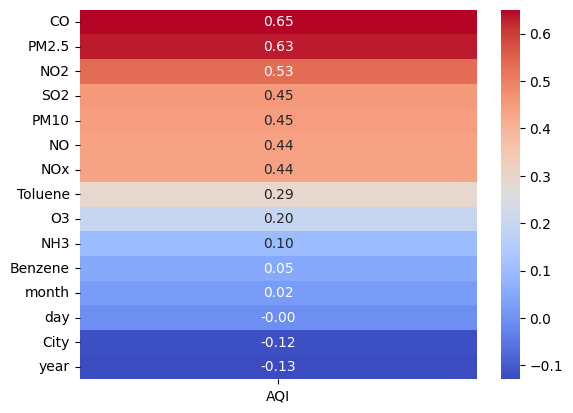

In [ ]:
# Analyze correlation of features with AQI and plot heatmap
aqi_cor=df.corr()['AQI'].sort_values(ascending=False)
aqi_cor=aqi_cor.drop('AQI')

sns.heatmap(aqi_cor.to_frame(),annot=True,fmt='0.02f',cmap='coolwarm')
plt.show()

In [ ]:
# Drop less relevant features for modeling
df=df.drop(['City','year','month','day','Benzene','NH3','O3','Toluene','NOx','PM10'],axis=1)

In [ ]:
# Display a sample after feature selection
df.sample()

,PM2.5,NO,NO2,CO,SO2,AQI
19426,66.57,2.95,17.89,0.46,1.67,124.0


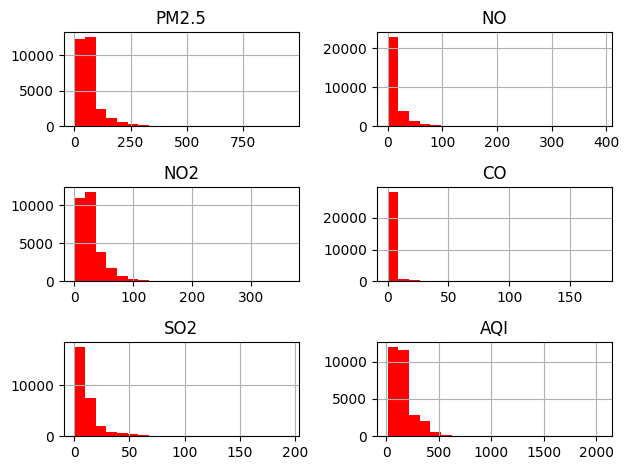

In [ ]:
# Plot histograms of features to visualize distributions
df.hist(color='red',bins=20)
plt.tight_layout()
plt.show()

In [ ]:
# Apply log transformation to reduce skewness in selected features
df['PM2.5'] = np.log1p(df['PM2.5'])
df['NO'] = np.log1p(df['NO'])
df['NO2'] = np.log1p(df['NO2'])
df['CO'] = np.log1p(df['CO'])
df['SO2'] = np.log1p(df['SO2'])
df['AQI'] = np.log1p(df['AQI'])

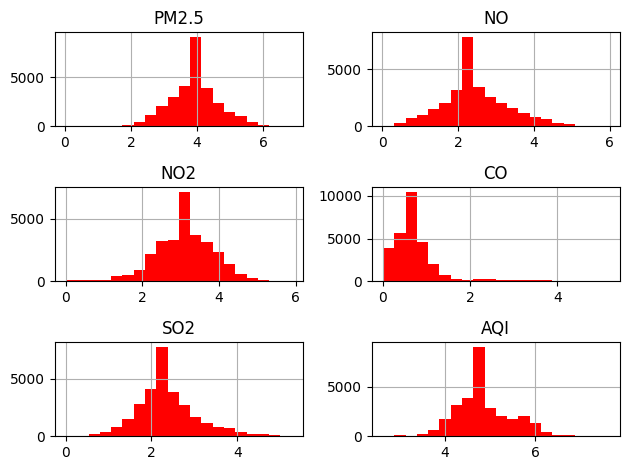

In [ ]:
# Plot histograms again after log transformation
df.hist(color='red',bins=20)
plt.tight_layout()
plt.show()

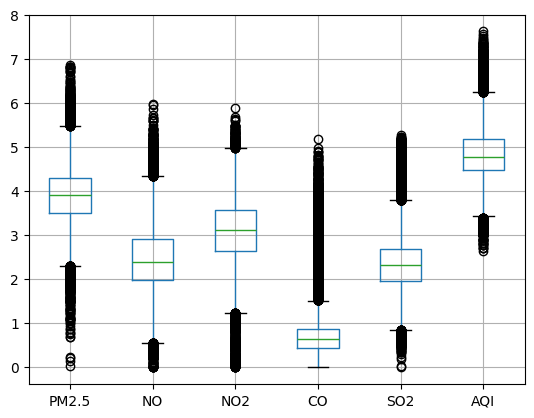

In [ ]:
# Visualize feature distributions using boxplot
df.boxplot()
plt.show()

In [ ]:
# Detect outliers in features using z-score
from scipy import stats

z_score = np.abs(stats.zscore(df['PM2.5']))
outliers=df[z_score>2]
print(f'\nNo of outliers in PM2.5 : {outliers.shape[0]}')


z_score = np.abs(stats.zscore(df['NO']))
outliers=df[z_score>2]
print(f'\nNo of outliers in NO : {outliers.shape[0]}')


z_score = np.abs(stats.zscore(df['NO2']))
outliers=df[z_score>2]
print(f'\nNo of outliers in NO2 : {outliers.shape[0]}')


z_score = np.abs(stats.zscore(df['CO']))
outliers=df[z_score>2]
print(f'\nNo of outliers in CO : {outliers.shape[0]}')


z_score = np.abs(stats.zscore(df['SO2']))
outliers=df[z_score>2]
print(f'\nNo of outliers in SO2 : {outliers.shape[0]}')


z_score = np.abs(stats.zscore(df['AQI']))
outliers=df[z_score>2]
print(f'\nNo of outliers in AQI : {outliers.shape[0]}')


No of outliers in PM2.5 : 1710

No of outliers in NO : 1945

No of outliers in NO2 : 1494

No of outliers in CO : 1543

No of outliers in SO2 : 1837

No of outliers in AQI : 1318


In [ ]:
# Remove outliers using IQR method, excluding AQI column
def outlier_removal(df,exclude_column):
  for col in df.columns:
    if col == exclude_column:
      continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
  return df

df_cleaned = outlier_removal(df,exclude_column='AQI')
df_cleaned

,PM2.5,NO,NO2,CO,SO2,AQI
0,3.903386,0.652325,2.955951,0.652325,3.354804,4.779123
1,3.903386,0.678034,2.814810,0.678034,3.240637,4.779123
3,3.903386,0.993252,2.969388,0.993252,2.975019,4.779123
9,3.903386,2.387845,2.084429,0.636577,2.228939,4.779123
34,4.402442,1.214913,3.170945,1.214913,3.285787,5.686975
...,...,...,...,...,...,...
29524,2.670694,1.193922,3.117950,0.343590,2.218116,4.356709
29526,2.773838,2.161022,3.260402,0.385262,2.256541,3.737670
29527,3.233961,1.486140,3.298057,0.418710,2.618855,4.262680
29528,3.174297,1.492904,3.418710,0.392042,2.242835,4.234107


In [ ]:
# Update the dataframe with cleaned data
df=df_cleaned

In [ ]:
# Select features and split data into train and test sets
x=df[['CO','PM2.5','NO','NO2','SO2']]
y=df['AQI']

x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# Train a linear regression model
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Make predictions and evaluate model performance
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [ ]:
# Print regression metrics
print(f"MSE: {mse:0.2f}, RMSE: {rmse:0.2f}, R-squared: {r2:0.2f}")

MSE: 0.07, RMSE: 0.26, R-squared: 0.73


In [ ]:
# Import scalers for feature normalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [ ]:
# Apply MinMax scaling to features
features = ['CO','PM2.5','NO','NO2','SO2']

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

df_scaled = pd.DataFrame(scaled_data,columns=features,index=df.index)



In [ ]:
# Display a sample of the scaled dataframe
df_scaled.sample()

,CO,PM2.5,NO,NO2,SO2
12465,0.444319,0.501301,0.486229,0.508547,0.517301


In [ ]:
# Use scaled features for train-test split
x=df_scaled
y=df['AQI']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# Train linear regression model on scaled data
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Evaluate model performance on scaled data
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [ ]:
# Print regression metrics for scaled model
print(f"MSE: {mse:0.2f}, RMSE: {rmse:0.2f}, R-squared: {r2:0.2f}")

MSE: 0.06, RMSE: 0.25, R-squared: 0.74


In [ ]:
# Apply Standard scaling to features
features = ['CO','PM2.5','NO','NO2','SO2']

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[features])

df_scaled2 = pd.DataFrame(scaled_data,columns=features,index=df.index)



In [ ]:
# Use standard scaled features for train-test split
x=df_scaled2
y=df['AQI']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# Train linear regression model on standard scaled data
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Evaluate model performance on standard scaled data
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [ ]:
# Print regression metrics for standard scaled model
print(f"MSE: {mse:0.2f}, RMSE: {rmse:0.2f}, R-squared: {r2:0.2f}")

MSE: 0.06, RMSE: 0.25, R-squared: 0.74


 Conclusion

In this notebook, we built and evaluated linear regression models to predict Air Quality Index (AQI) using city-level air pollution data.

We performed three tests:
- **Outliers removed - Non Scaled Model:** Evaluated using MSE, RMSE, and R-squared metrics.
- **MinMax Scaled Model:** Evaluated using MSE, RMSE, and R-squared metrics.
- **Standard Scaled Model:** Evaluated using MSE, RMSE, and R-squared metrics.

Both approaches provided insights into the effectiveness of feature scaling on model performance. The results can be used to further improve air quality prediction models or to compare with other machine learning techniques.

---

In [ ]:
import joblib
joblib.dump(model,'air_quality_model.pkl')

['air_quality_model.pkl']

In [ ]:
#Import ensemble models
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
# ===== LINEAR REGRESSION MODEL =====
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

lr_pred = lr_model.predict(x_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, lr_pred))
print("Linear Regression RMSE:", root_mean_squared_error(y_test, lr_pred))

Linear Regression R2: 0.7438176509879288
Linear Regression MAE: 0.1801899926243417
Linear Regression MSE: 0.06272480515055355
Linear Regression RMSE: 0.2504492067277386


In [ ]:
# ===== RANDOM FOREST WITH GRID SEARCH =====

rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)

# Best tuned model
rf_model = rf_grid.best_estimator_

print("Best RF Parameters:", rf_grid.best_params_)

rf_pred = rf_model.predict(x_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))
print("Random Forest RMSE:", root_mean_squared_error(y_test, rf_pred))

Best RF Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest R2: 0.7991820127131226
Random Forest MAE: 0.14732033480595852
Random Forest MSE: 0.049169153034435614
Random Forest RMSE: 0.2217411847953276


In [ ]:
# ===== GRADIENT BOOSTING WITH GRID SEARCH =====

gb = GradientBoostingRegressor()

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gb_grid.fit(x_train, y_train)

# Best tuned model
gb_model = gb_grid.best_estimator_

print("Best GB Parameters:", gb_grid.best_params_)

gb_pred = gb_model.predict(x_test)

print("Gradient Boosting R2:", r2_score(y_test, gb_pred))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, gb_pred))
print("Gradient Boosting MSE:", mean_squared_error(y_test, gb_pred))
print("Gradient Boosting RMSE:", root_mean_squared_error(y_test, gb_pred))

Best GB Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Gradient Boosting R2: 0.799469439738909
Gradient Boosting MAE: 0.14927192142180631
Gradient Boosting MSE: 0.049098778146169565
Gradient Boosting RMSE: 0.22158244096987822


In [ ]:
#Create HYBRID Ensemble Prediction
lr_pred = lr_model.predict(x_test)

from sklearn.linear_model import LinearRegression

# Combine predictions
meta_X = np.column_stack((lr_pred, rf_pred, gb_pred))

# Train meta model
meta_model = LinearRegression()
meta_model.fit(meta_X, y_test)

# Final prediction
final_pred = meta_model.predict(meta_X)

print("Stacked Model R2:", r2_score(y_test, final_pred))
print("MAE:", mean_absolute_error(y_test, final_pred))
print("MSE:", mean_squared_error(y_test, final_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))


Stacked Model R2: 0.8040469755245716
MAE: 0.14685846480562917
MSE: 0.047977994293056256
RMSE: 0.21903879631941062


In [ ]:
#Save ALL models (very important)
import joblib

joblib.dump(model, "linear_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(gb_model, "gb_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

# Load dataset
df = pd.read_csv(r"C:\MDM\static\city_day.csv")
df.columns = df.columns.str.strip()
df = df.dropna()

features = ["PM2.5", "PM10", "NO2", "CO", "SO2", "O3"]
target = "AQI"

X = df[features]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Base models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)

# 🔥 Stacking (Meta Regressor)
stack_model = StackingRegressor(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('gb', gb)
    ],
    final_estimator=LinearRegression()
)

# Train model
stack_model.fit(x_train, y_train)

# Save model
pickle.dump(stack_model, open("stack_model.pkl", "wb"))

print("✅ Stack model trained and saved successfully!")

✅ Stack model trained and saved successfully!
